**Sobel Edge Detection**

In [1]:
import cv2
import numpy as np
img = cv2.imread('son.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)
sobel_x_kernel = np.array([[-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1],
 [0, 0, 0],
 [1, 2, 1]])
sobelx = cv2.filter2D(img_blur, ddepth=cv2.CV_64F, kernel=sobel_x_kernel)
sobely = cv2.filter2D(img_blur, ddepth=cv2.CV_64F, kernel=sobel_y_kernel)
sobelx = np.abs(sobelx)
sobely = np.abs(sobely)
sobelxy = np.sqrt(sobelx**2 + sobely**2)
sobelxy = (sobelxy / sobelxy.max()) * 255
sobelx = np.uint8(255 * (sobelx - sobelx.min()) / (sobelx.max() - sobelx.min()))
sobely = np.uint8(255 * (sobely - sobely.min()) / (sobely.max() - sobely.min()))
sobelxy = np.uint8(255 * (sobelxy - sobelxy.min()) / (sobelxy.max() - sobelxy.min()))
cv2.imshow('Original Image', img_gray)
cv2.waitKey(0)
cv2.imshow('Sobel X', sobelx)
cv2.waitKey(0)
cv2.imshow('Sobel Y', sobely)
cv2.waitKey(0)
cv2.imshow('Sobel XY', sobelxy)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Salt and Pepper Noise**

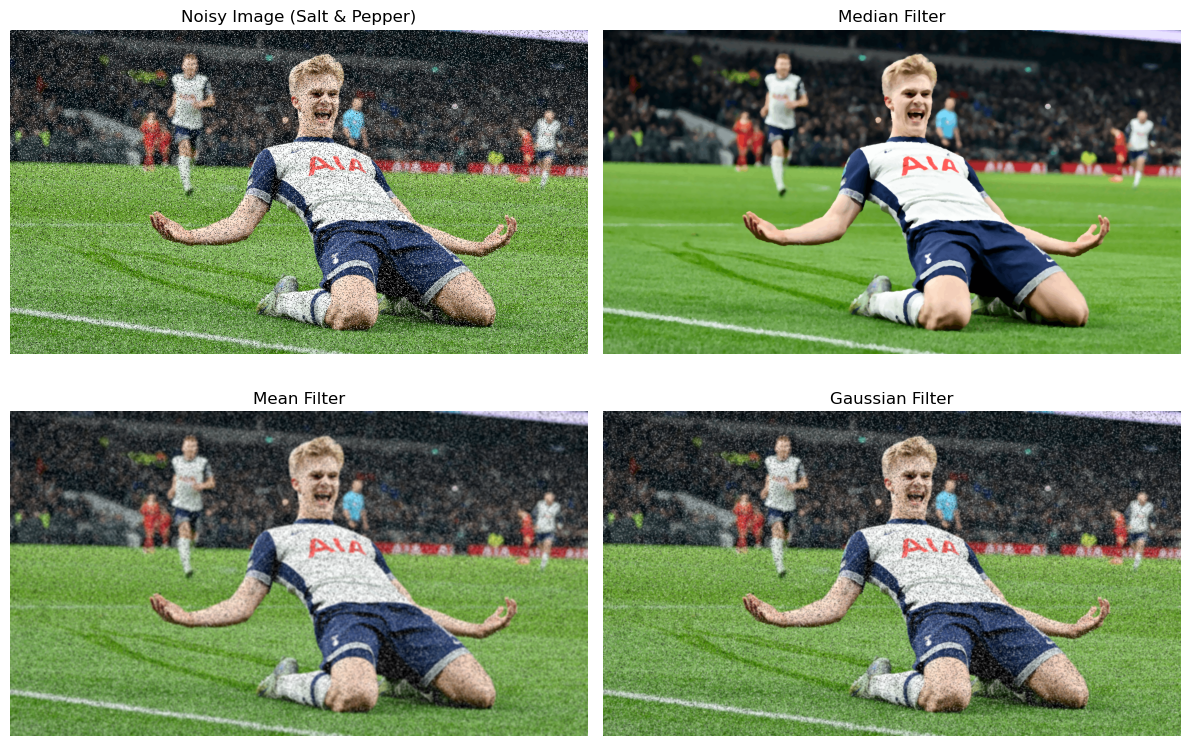

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def salt_and_pepper_noise(image, amount=0.1):
    h, w, c = image.shape
    noisy_image = image.copy()
    num_salt = num_pepper = int(amount * h * w * 0.5)
    for val, num in [(255, num_salt), (0, num_pepper)]:
        coords = [np.random.randint(0, i - 1, num) for i in (h, w)]
        noisy_image[coords[0], coords[1], :] = val
    return noisy_image

image = cv2.cvtColor(cv2.imread('berg.png'), cv2.COLOR_BGR2RGB)
noisy = salt_and_pepper_noise(image, 0.2)

filters = {
    "Median Filter": cv2.medianBlur(noisy, 5),
    "Mean Filter": cv2.blur(noisy, (5, 5)),
    "Gaussian Filter": cv2.GaussianBlur(noisy, (5, 5), 0)
}

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noisy)
plt.title("Noisy Image (Salt & Pepper)")
plt.axis("off")

for i, (name, img) in enumerate(filters.items(), 2):
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()



**Poisson Noise**

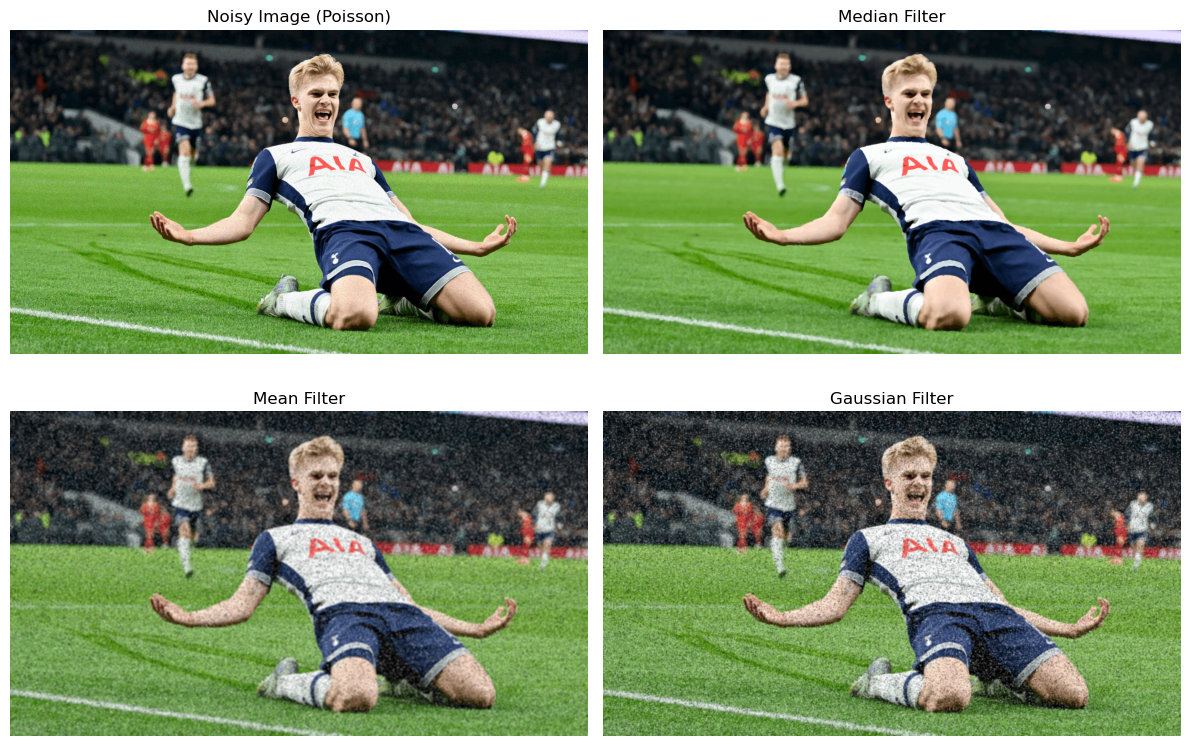

In [13]:
def poisson_noise(image):
    noisy_image = np.random.poisson(image.astype(np.float32))
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

noisy = poisson_noise(image)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(noisy)
plt.title("Noisy Image (Poisson)")
plt.axis("off")

for i, (name, img) in enumerate(filters.items(), 2):
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


**Gaussian Noise**

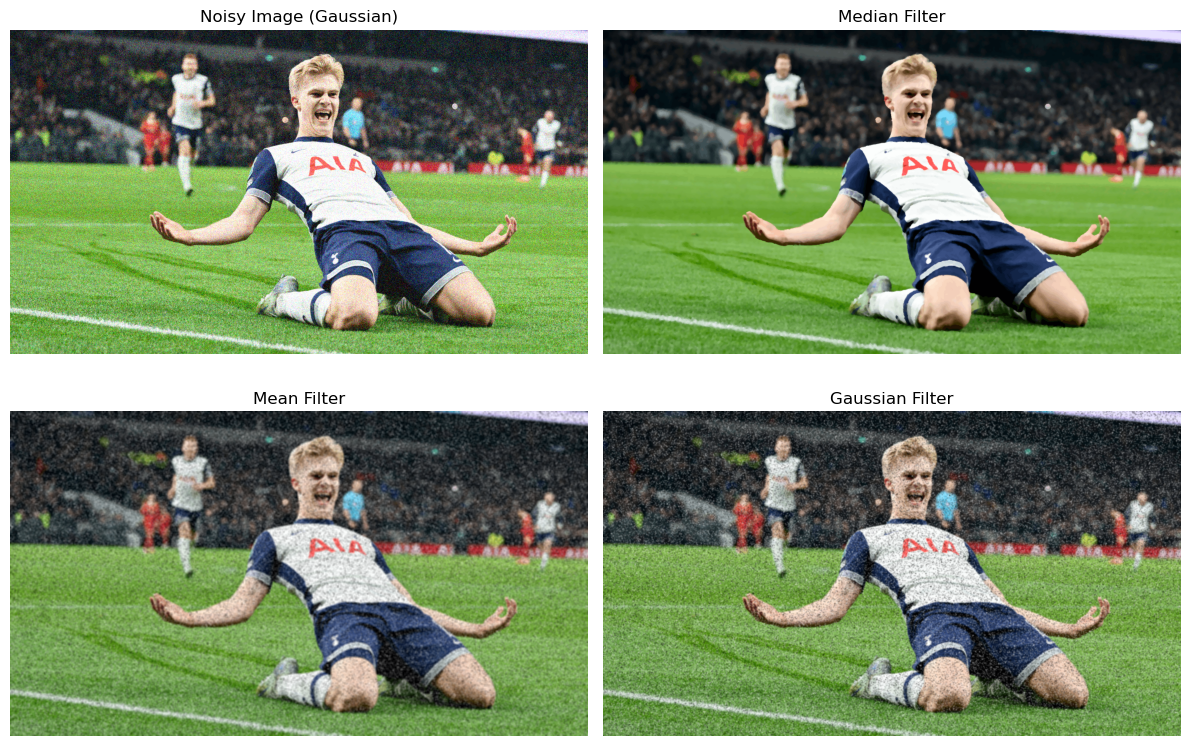

In [18]:
def gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.int16)
    noisy_image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return noisy_image

noisy = gaussian_noise(image, mean=15, std=30)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(noisy)
plt.title("Noisy Image (Gaussian)")
plt.axis("off")

for i, (name, img) in enumerate(filters.items(), 2):
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()
